In [28]:
from torch_geometric.datasets import TUDataset
import numpy as np

dataset = TUDataset(root="/tmp/MUTAG", name="MUTAG", use_node_attr=True).shuffle()
graph = dataset[0]
# let's inspect the data
print(f"The dataset has {len(dataset)} graphs.")
print(f"Each graph has {dataset.num_features} features.")
print(f"Number of classes: {dataset.num_classes}")

edges = np.array([data.num_edges for data in dataset])
nodes = np.array([data.num_nodes for data in dataset])
mean_edges = edges.mean().item()
mean_nodes = nodes.mean().item()
avg_degree = (edges/nodes).mean().item()

print(f"Average number of nodes per graph: {mean_nodes:.2f}")
print(f"Average number of edges per graph: {mean_edges:.2f}")
print(f"Is the first graph undircted? {graph.is_undirected()}")
print(f"Does the graph have isolated nodes? {graph.has_isolated_nodes()}")
print(f"Does the graph have self loops? {graph.has_self_loops()}")
print(f"Average degree: {avg_degree:.2f}")

The dataset has 188 graphs.
Each graph has 7 features.
Number of classes: 2
Average number of nodes per graph: 17.93
Average number of edges per graph: 39.59
Is the first graph undircted? True
Does the graph have isolated nodes? False
Does the graph have self loops? False
Average degree: 2.19


In [ ]:
import torch.nn as nn
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool
from torch_geometric.loader import DataLoader
import torch
from torch_geometric.data import Data
from torch.functional import F

# prepare the dataloader
train_size = round(0.7 * len(dataset))
val_size = round(0.15 * len(dataset))

train_data = dataset[:train_size]
val_data = dataset[train_size: train_size+val_size]
test_data = dataset[train_size+val_size:]

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64)

class GCN(nn.Module):
    def __init__(self, in_channel: int, hidden_channel: int, out_channel: int, p: float, num_classes: int):
        super().__init__()

        self.in_channel = in_channel
        self.hidden_channel = hidden_channel
        self.out_channel = out_channel
        self.p = p
        self.num_classes = num_classes

        self.conv_in = GCNConv(self.in_channel, self.hidden_channel, add_self_loops=True)
        self.conv_out = GCNConv(self.hidden_channel, self.out_channel, add_self_loops=True)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=self.p)

        self.classifer_head = nn.Linear(self.out_channel, self.num_classes)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, batch: torch.Tensor):
        x = self.conv_in(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv_out(x, edge_index)
        x = self.relu(x)
        hidden = self.dropout(x)

        x = global_mean_pool(x, batch)
        x = self.classifer_head(x)
        return x, hidden
    
first_batch = [*train_loader][0]

in_channel = dataset.num_features
hidden_channel = 32
out_channel = 64
num_classes = dataset.num_classes

# test forward prop
model = GCN(in_channel, hidden_channel, out_channel, 0.5, num_classes)
model(first_batch.x, first_batch.edge_index, first_batch.batch)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

def acc(model: GCN, data: Data):
    model.eval()
    with torch.no_grad():
        out, _ = model(data.x, data.edge_index, data.batch)
        prob = F.sigmoid(out)
        y_pred = torch.argmax(prob, dim=1)
        return (y_pred == data.y).float().mean()

def train(model: GCN, optimizer: torch.optim.Adam, criterion: nn.CrossEntropyLoss, train_data: Data):
    model.train()
    optimizer.zero_grad()
    out, _ = model(train_data.x, train_data.edge_index, train_data.batch)
    loss = criterion(out, train_data.y)
    loss.backward()
    optimizer.step()
    accuracy = acc(model, train_data)
    return loss, accuracy

def val(model: GCN, criterion: nn.CrossEntropyLoss, val_data: Data):
    model.eval()
    with torch.no_grad():
        out, _ = model(val_data.x, val_data.edge_index, val_data.batch)
        loss = criterion(out, val_data.y)
        accuracy = acc(model, val_data)
        return loss, accuracy
    
epochs = 500

def train_val(model: GCN, epochs: int, optimizer: torch.optim, criterion:nn.CrossEntropyLoss, train_loader: DataLoader, val_loader: DataLoader):
    
    train_l = []
    val_l = []

    train_a = []
    val_a = []

    for _ in range(epochs):
        train_loss = 0
        val_loss = 0

        train_acc = 0
        val_acc = 0

        for train_data in train_loader:
            loss, acc = train(model, optimizer, criterion, train_data)
            train_loss += loss.detach().item()
            train_acc += acc.item()

        for val_data in val_loader:
            loss, acc = val(model, criterion, val_data) 
            val_loss += loss.detach().item()
            val_acc += acc.item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        train_acc /= len(train_loader)
        val_acc /= len(val_loader)

        train_l.append(train_loss)
        val_l.append(val_loss)

        train_a.append(train_acc)
        val_a.append(val_acc)

    return {
        "model": model,
        "train_loss": train_l,
        "val_loss": val_l,
        "train_acc": train_a,
        "val_acc": val_a
    }

output = train_val(model, epochs, optimizer, criterion, train_loader, val_loader)

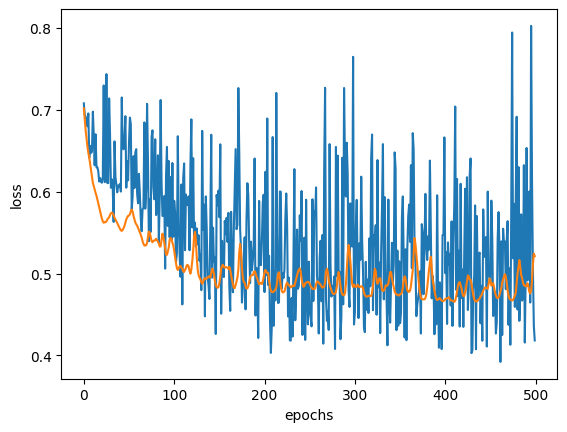

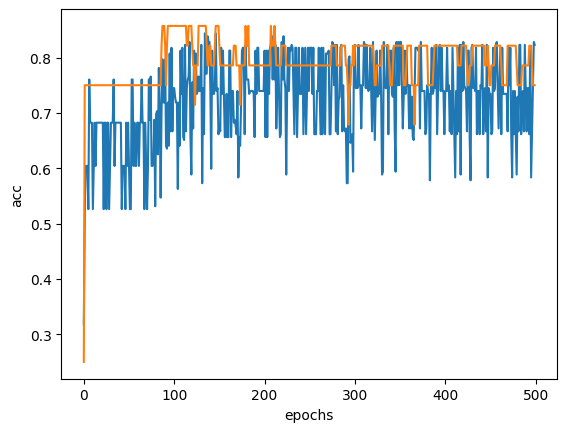

In [ ]:
import matplotlib.pyplot as plt

plt.plot(output["train_loss"], label="train_loss")
plt.plot(output["val_loss"], label="val_loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

plt.plot(output["train_acc"], label="train_acc")
plt.plot(output["val_acc"], label="val_acc")
plt.xlabel("epochs")
plt.ylabel("acc")
plt.show()

In [86]:
from torch_geometric.data import Batch

test_data_all = Batch.from_data_list(test_data)
(acc(output["model"], test_data_all)).item()

0.75